# 1. Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
import torchmetrics
from torchmetrics import JaccardIndex, F1Score, Accuracy, Precision, Recall, Specificity
from medpy.metric import binary  # for Hausdorff distance

# Custom Dice metric (if needed, but torchmetrics.Dice works for binary)
# We'll use torchmetrics directly.

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
%matplotlib inline
import matplotlib

Using device: cuda


In [2]:
from torchmetrics.segmentation import DiceScore

# 2. Configuration

In [12]:
# Paths
data_dir = r"C:\Users\PC\Desktop\unetcodes\Kvasir-SEG"
image_dir = os.path.join(data_dir, "images")
mask_dir = os.path.join(data_dir, "masks")

# Binary segmentation: 0=background, 1=polyp
num_classes = 2
class_names = ['background', 'polyp']

# Image size after resizing (choose e.g., 256x256 or 320x320)
IMG_HEIGHT = 256
IMG_WIDTH = 256

# Train/val/test split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Training hyperparameters
batch_size = 8        # Adjust based on GPU memory (8GB may handle 8-16 with 256x256)
learning_rate = 1e-4 
num_epochs = 100
patience = 40000

# Output directories
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 3. Dataset Class with Albumentations

In [4]:
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read image (RGB)
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask (grayscale, values 0 or 1)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        # Ensure mask is binary (0/1) – sometimes masks may have 0/255
        mask = (mask > 0).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Convert to tensor if no transform
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return image, mask

# 4. Create Train/Val/Test Splits

In [5]:
# Get all image and mask filenames (assume same names)
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

# Ensure matching names (optional check)
assert len(image_files) == len(mask_files), "Mismatch between images and masks"

# Create full paths
image_paths = [os.path.join(image_dir, f) for f in image_files]
mask_paths = [os.path.join(mask_dir, f) for f in mask_files]

# Shuffle and split
data = list(zip(image_paths, mask_paths))
random.shuffle(data)
n = len(data)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 700, Val: 150, Test: 150


# 5. Define Albumentations Transforms

In [6]:
# Training transforms (include resizing and augmentations)
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # ImageNet stats
    ToTensorV2()
])

# Validation/Test transforms (only resizing and normalization)
val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Create datasets
train_dataset = KvasirDataset(*zip(*train_data), transform=train_transform)
val_dataset = KvasirDataset(*zip(*val_data), transform=val_transform)
test_dataset = KvasirDataset(*zip(*test_data), transform=val_transform)

# 6. Visualize a Few Samples (Sanity Check)

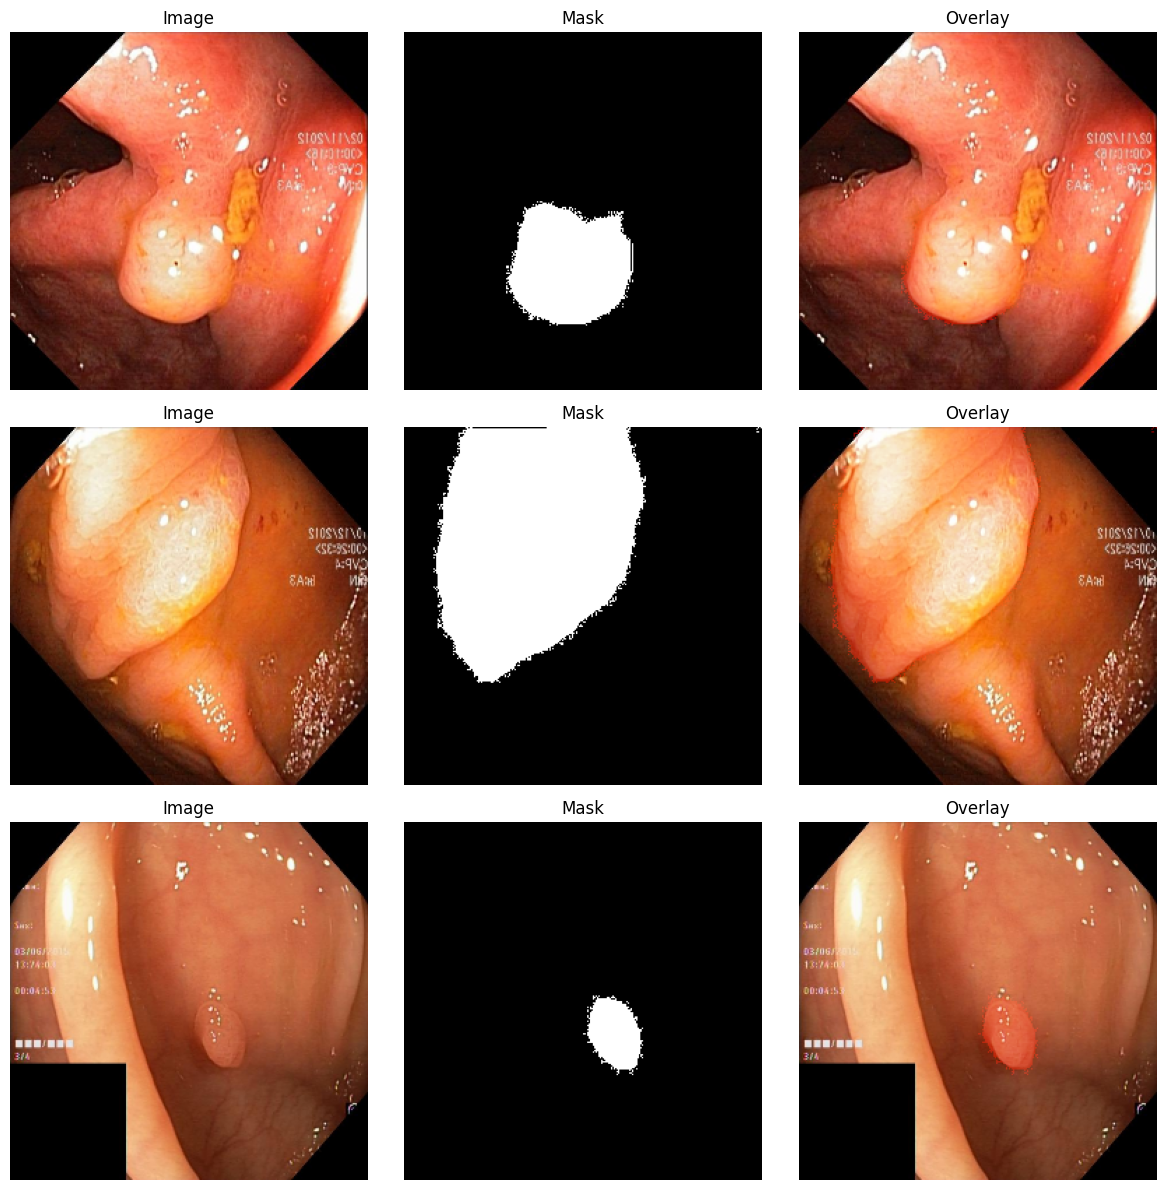

In [7]:
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))
    for i in range(num_samples):
        idx = random.randint(0, len(dataset)-1)
        img, mask = dataset[idx]
        # Denormalize for display (approx)
        img_np = img.permute(1,2,0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask.numpy()

        axes[i,0].imshow(img_np)
        axes[i,0].set_title('Image')
        axes[i,0].axis('off')

        axes[i,1].imshow(mask_np, cmap='gray')
        axes[i,1].set_title('Mask')
        axes[i,1].axis('off')

        # Overlay
        overlay = img_np.copy()
        overlay[:,:,0] = np.where(mask_np>0, 0.5*img_np[:,:,0] + 0.5, img_np[:,:,0])
        axes[i,2].imshow(overlay)
        axes[i,2].set_title('Overlay')
        axes[i,2].axis('off')
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, num_samples=3)

# 7. model

In [9]:
# Import the UNetV2 model (make sure UNet_v2.py and pvtv2.py are in the same folder)
from UNet_v2 import UNetV2


# Model parameters
# For binary segmentation, n_classes=1, output is raw logits (no sigmoid)
# deep_supervision=False gives a single output mask (simpler for your existing loss)
model = UNetV2(
    n_classes=1,
    deep_supervision=False,         # single output (logits)
    pretrained_path=None            # set to path of pvt_v2_b2.pth if you have it
).to(device)

In [10]:
# Print model size
total_params = sum(p.numel() for p in model.parameters())
print(f"UNetV2 total parameters: {total_params/1e6:.2f}M")

UNetV2 total parameters: 25.15M


# 8. Loss Function: Dice + Binary Cross Entropy (or Focal)

In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super(DiceBCELoss, self).__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets):
        # inputs: (N,1,H,W) raw logits
        # targets: (N,H,W) long (0/1)
        inputs = inputs.squeeze(1)  # (N,H,W)
        targets = targets.float()

        # Dice loss
        smooth = 1e-5
        probs = torch.sigmoid(inputs)
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

        # BCE loss
        bce_loss = self.bce(inputs, targets)

        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

# Alternatively, Focal Loss for binary
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        inputs = inputs.squeeze(1)
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        focal_loss = ((1 - pt) ** self.gamma * bce).mean()
        return focal_loss

# Choose which loss to use
criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5).to(device)
# criterion = FocalLoss(gamma=2).to(device)

# 9. Metrics Setup

In [13]:


# Binary segmentation metrics – all return a single scalar
jaccard = JaccardIndex(task='binary').to(device)
dice = F1Score(task='binary').to(device)      # F1Score = Dice for binary
accuracy = Accuracy(task='binary').to(device)
precision = Precision(task='binary').to(device)
recall = Recall(task='binary').to(device)
specificity = Specificity(task='binary').to(device)

def compute_hausdorff(pred_mask, true_mask, spacing=(1,1)):
    """
    pred_mask, true_mask: 2D numpy arrays with values 0/1
    Returns HD and HD95 for the foreground class.
    """
    pred_binary = pred_mask.astype(np.uint8)
    true_binary = true_mask.astype(np.uint8)
    if np.sum(pred_binary) == 0 or np.sum(true_binary) == 0:
        return np.nan, np.nan
    hd = binary.hd(pred_binary, true_binary, voxelspacing=spacing)
    hd95 = binary.hd95(pred_binary, true_binary, voxelspacing=spacing)
    return hd, hd95

# 10. DataLoaders

In [14]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# 11. Model, Optimizer, Scheduler

In [15]:
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

In [ ]:
print(next(model.parameters()).device)   # Should print cuda:0

cuda:0


In [16]:
from ptflops import get_model_complexity_info
# Input size: (batch, channels, height, width) – batch dimension is ignored by ptflops
input_size = (3, 512, 512)   # RGB, 512x512

# Compute FLOPs and parameters
macs, params = get_model_complexity_info(model, input_size, as_strings=True, print_per_layer_stat=False)
print(f"GFLOPs: {macs}")
print(f"Parameters: {params}")

GFLOPs: 21.52 GMac
Parameters: 25.15 M


# 12. Training and Validation Functions

In [17]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total_pixels = 0

    for images, masks in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # (N,1,H,W)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Compute pixel accuracy
        preds = (torch.sigmoid(outputs) > 0.5).squeeze(1).long()
        correct += (preds == masks).sum().item()
        total_pixels += masks.numel()

    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total_pixels
    return avg_loss, avg_acc

def evaluate_one_epoch(model, dataloader, criterion, device):
    """
    Compute loss and all metrics (accuracy, jaccard, dice, precision, recall, specificity, HD, HD95)
    on the given dataloader (could be train, val, or test).
    """
    model.eval()
    total_loss = 0

    # Reset all metrics
    jaccard.reset()
    dice.reset()
    accuracy.reset()
    precision.reset()
    recall.reset()
    specificity.reset()

    hd_list = []
    hd95_list = []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Evaluation'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).squeeze(1).long()

            jaccard.update(preds, masks)
            dice.update(preds, masks)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            specificity.update(preds, masks)

            for i in range(images.size(0)):
                pred_np = preds[i].cpu().numpy()
                mask_np = masks[i].cpu().numpy()
                hd, hd95 = compute_hausdorff(pred_np, mask_np)
                hd_list.append(hd)
                hd95_list.append(hd95)

    avg_loss = total_loss / len(dataloader)

    jaccard_score = jaccard.compute().cpu().item()
    dice_score = dice.compute().cpu().item()
    acc_score = accuracy.compute().cpu().item()
    prec_score = precision.compute().cpu().item()
    rec_score = recall.compute().cpu().item()
    spec_score = specificity.compute().cpu().item()
    hd_mean = np.nanmean(hd_list)
    hd95_mean = np.nanmean(hd95_list)

    metrics = {
        'loss': avg_loss,
        'accuracy': acc_score,
        'jaccard': jaccard_score,
        'dice': dice_score,
        'precision': prec_score,
        'recall': rec_score,
        'specificity': spec_score,
        'hd_mean': hd_mean,
        'hd95_mean': hd95_mean
    }
    return metrics

# 13. Training Loop with CSV Logging

In [18]:
# CSV logging – add columns for train metrics
log_file = "logs/training_log.csv"
csv_columns = ['epoch',
               'train_loss', 'train_accuracy', 'train_jaccard', 'train_dice',
               'train_precision', 'train_recall', 'train_specificity',
               'train_hd_mean', 'train_hd95_mean',
               'val_loss', 'val_accuracy', 'val_jaccard', 'val_dice',
               'val_precision', 'val_recall', 'val_specificity',
               'val_hd_mean', 'val_hd95_mean']

if not os.path.exists(log_file):
    pd.DataFrame(columns=csv_columns).to_csv(log_file, index=False)

best_val_loss = float('inf')
patience_counter = 0
history = defaultdict(list)

for epoch in range(1, num_epochs+1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    # Training pass (returns loss and accuracy only)
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Compute full training metrics (this will evaluate on the whole training set)
    train_metrics = evaluate_one_epoch(model, train_loader, criterion, device)

    # Compute validation metrics
    val_metrics = evaluate_one_epoch(model, val_loader, criterion, device)

    # Update scheduler using validation loss
    scheduler.step(val_metrics['loss'])

    # Store history
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    for k, v in train_metrics.items():
        history[f'train_{k}'].append(v)
    for k, v in val_metrics.items():
        history[f'val_{k}'].append(v)

    # Print summary
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    print(f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"Train Jaccard: {train_metrics['jaccard']:.4f} | Val Jaccard: {val_metrics['jaccard']:.4f}")
    print(f"HD: {val_metrics['hd_mean']:.2f} | HD95: {val_metrics['hd95_mean']:.2f}")

    # Save to CSV (include both train and val metrics)
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'train_jaccard': train_metrics['jaccard'],
        'train_dice': train_metrics['dice'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_specificity': train_metrics['specificity'],
        'train_hd_mean': train_metrics['hd_mean'],
        'train_hd95_mean': train_metrics['hd95_mean'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_jaccard': val_metrics['jaccard'],
        'val_dice': val_metrics['dice'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_specificity': val_metrics['specificity'],
        'val_hd_mean': val_metrics['hd_mean'],
        'val_hd95_mean': val_metrics['hd95_mean']
    }
    df = pd.DataFrame([row])
    df.to_csv(log_file, mode='a', header=False, index=False)

    # Save best model based on validation loss
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'models/best_unet.pth')
        print("Best model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

torch.save(model.state_dict(), 'models/final_unet.pth')


Epoch 1/100


Evaluation: 100%|██████████| 19/19 [00:03<00:00,  5.35it/s]


Train Loss: 0.5817 | Val Loss: 0.5032
Train Acc: 0.7962 | Val Acc: 0.8291
Train Dice: 0.4145 | Val Dice: 0.4811
Train Jaccard: 0.2614 | Val Jaccard: 0.3168
HD: 108.78 | HD95: 76.27
Best model saved!

Epoch 2/100


Evaluation: 100%|██████████| 19/19 [00:03<00:00,  5.53it/s]


Train Loss: 0.5300 | Val Loss: 0.5023
Train Acc: 0.8187 | Val Acc: 0.8412
Train Dice: 0.3423 | Val Dice: 0.3997
Train Jaccard: 0.2065 | Val Jaccard: 0.2498
HD: 103.67 | HD95: 73.66
Best model saved!

Epoch 3/100


...

Train Loss: 0.0275 | Val Loss: 0.3543
Train Acc: 0.9921 | Val Acc: 0.9302
Train Dice: 0.9756 | Val Dice: 0.7900
Train Jaccard: 0.9524 | Val Jaccard: 0.6528
HD: 60.94 | HD95: 38.48

Epoch 99/100


Evaluation: 100%|██████████| 19/19 [00:03<00:00,  5.50it/s]


Train Loss: 0.0269 | Val Loss: 0.3629
Train Acc: 0.9922 | Val Acc: 0.9294
Train Dice: 0.9759 | Val Dice: 0.7846
Train Jaccard: 0.9530 | Val Jaccard: 0.6456
HD: 59.80 | HD95: 37.34

Epoch 100/100


Evaluation: 100%|██████████| 19/19 [00:03<00:00,  5.47it/s]


Train Loss: 0.0276 | Val Loss: 0.3635
Train Acc: 0.9920 | Val Acc: 0.9302
Train Dice: 0.9755 | Val Dice: 0.7874
Train Jaccard: 0.9523 | Val Jaccard: 0.6494
HD: 59.15 | HD95: 37.21


# 14. Plot Training Curves

Truncating all lists to minimum length: 100


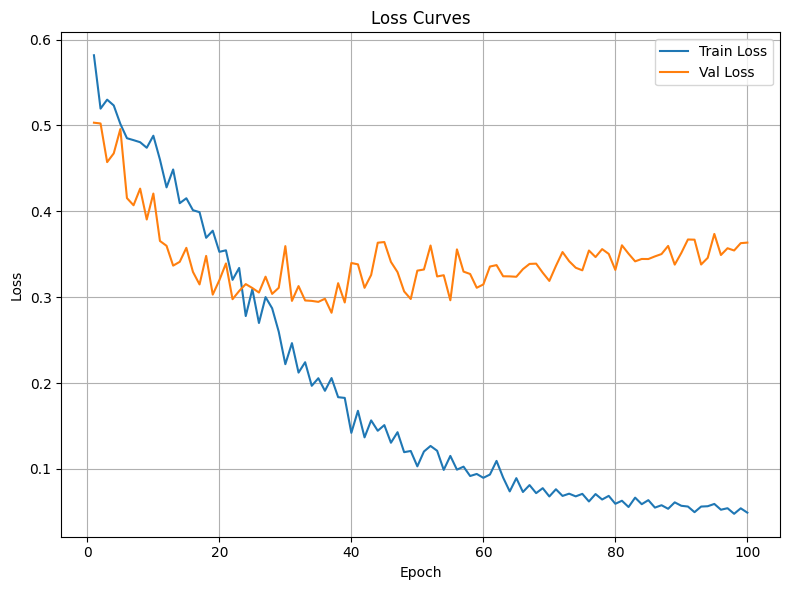

Saved: results/loss_curve.png


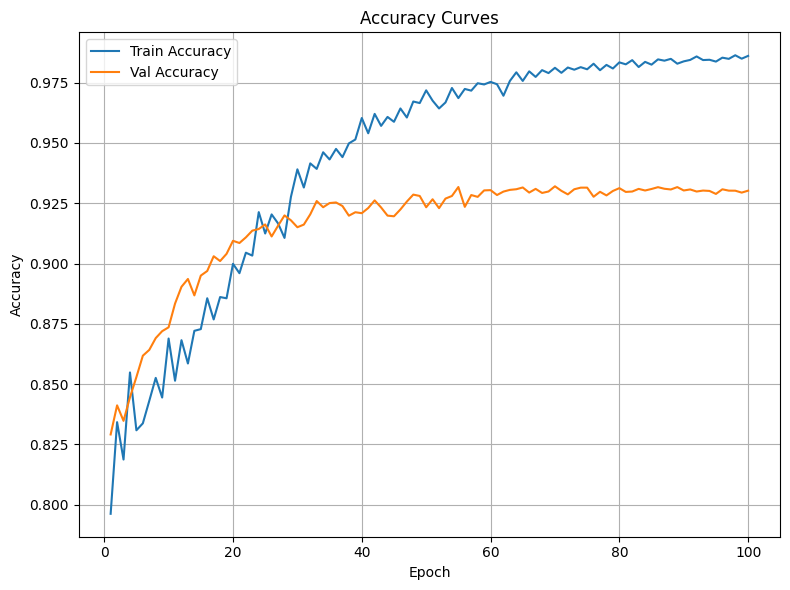

Saved: results/accuracy_curve.png


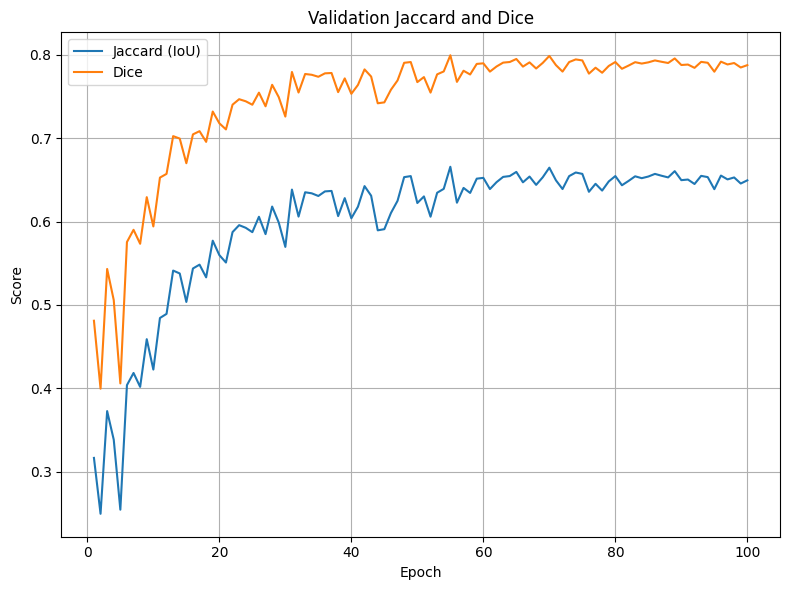

Saved: results/jaccard_dice_curve.png


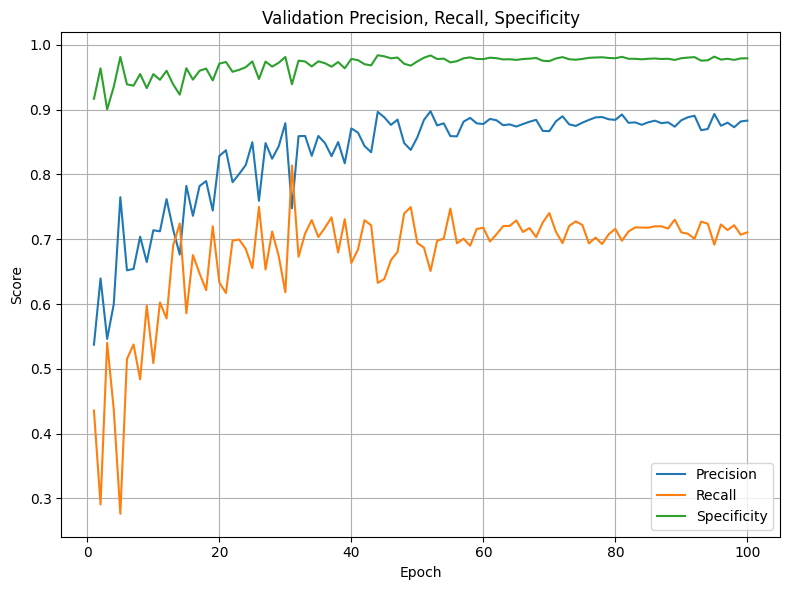

Saved: results/precision_recall_specificity.png


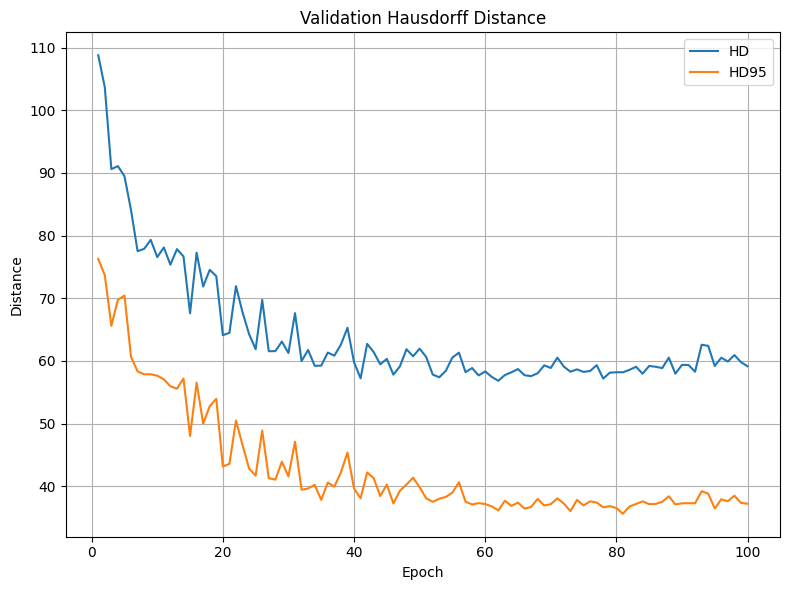

Saved: results/hausdorff_curve.png


In [21]:
def plot_individual_curves(history):
    os.makedirs("results", exist_ok=True)
    
    # Find the minimum length among all keys
    min_len = min(len(v) for v in history.values())
    print(f"Truncating all lists to minimum length: {min_len}")
    
    # Truncate each list
    truncated = {k: v[:min_len] for k, v in history.items()}
    epochs = truncated['epoch']
    
    # Loss
    plt.figure(figsize=(8,6))
    plt.plot(epochs, truncated['train_loss'], label='Train Loss')
    plt.plot(epochs, truncated['val_loss'], label='Val Loss')   # fixed key
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/loss_curve.png', dpi=150)
    plt.show()
    print("Saved: results/loss_curve.png")
    
    # Accuracy
    plt.figure(figsize=(8,6))
    plt.plot(epochs, truncated['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, truncated['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/accuracy_curve.png', dpi=150)
    plt.show()
    print("Saved: results/accuracy_curve.png")
    
    # Jaccard & Dice (validation curves)
    plt.figure(figsize=(8,6))
    plt.plot(epochs, truncated['val_jaccard'], label='Jaccard (IoU)')
    plt.plot(epochs, truncated['val_dice'], label='Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Jaccard and Dice')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/jaccard_dice_curve.png', dpi=150)
    plt.show()
    print("Saved: results/jaccard_dice_curve.png")
    
    # Precision/Recall/Specificity (validation)
    plt.figure(figsize=(8,6))
    plt.plot(epochs, truncated['val_precision'], label='Precision')
    plt.plot(epochs, truncated['val_recall'], label='Recall')
    plt.plot(epochs, truncated['val_specificity'], label='Specificity')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Precision, Recall, Specificity')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/precision_recall_specificity.png', dpi=150)
    plt.show()
    print("Saved: results/precision_recall_specificity.png")
    
    # Hausdorff (validation)
    plt.figure(figsize=(8,6))
    plt.plot(epochs, truncated['val_hd_mean'], label='HD')
    plt.plot(epochs, truncated['val_hd95_mean'], label='HD95')
    plt.xlabel('Epoch')
    plt.ylabel('Distance')
    plt.title('Validation Hausdorff Distance')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/hausdorff_curve.png', dpi=150)
    plt.show()
    print("Saved: results/hausdorff_curve.png")

plot_individual_curves(history)

# 15. Evaluate on Test Set

In [22]:
# Load best model
model.load_state_dict(torch.load('models/best_unet.pth'))
model.eval()

# Reset metrics
jaccard.reset()
dice.reset()
accuracy.reset()
precision.reset()
recall.reset()
specificity.reset()
hd_list = []
hd95_list = []
test_loss_total = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss_total += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).squeeze(1).long()

        jaccard.update(preds, masks)
        dice.update(preds, masks)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        specificity.update(preds, masks)

        for i in range(images.size(0)):
            pred_np = preds[i].cpu().numpy()
            mask_np = masks[i].cpu().numpy()
            hd, hd95 = compute_hausdorff(pred_np, mask_np)
            hd_list.append(hd)
            hd95_list.append(hd95)

avg_test_loss = test_loss_total / len(test_loader)

# Final metrics
jaccard_score = jaccard.compute().cpu().item()
dice_score = dice.compute().cpu().item()
acc_score = accuracy.compute().cpu().item()
prec_score = precision.compute().cpu().item()
rec_score = recall.compute().cpu().item()
spec_score = specificity.compute().cpu().item()
hd_mean = np.nanmean(hd_list)
hd95_mean = np.nanmean(hd95_list)

print("\n===== Test Set Results =====")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {acc_score:.4f}")
print(f"Jaccard: {jaccard_score:.4f}")
print(f"Dice: {dice_score:.4f}")
print(f"Precision: {prec_score:.4f}")
print(f"Recall: {rec_score:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"HD: {hd_mean:.2f}")
print(f"HD95: {hd95_mean:.2f}")

# Save test results
test_results = pd.DataFrame([{
    'loss': avg_test_loss,
    'accuracy': acc_score,
    'jaccard': jaccard_score,
    'dice': dice_score,
    'precision': prec_score,
    'recall': rec_score,
    'specificity': spec_score,
    'hd': hd_mean,
    'hd95': hd95_mean
}])
test_results.to_csv('results/test_metrics.csv', index=False)
print("Test metrics saved to results/test_metrics.csv")

Testing: 100%|██████████| 19/19 [00:03<00:00,  6.08it/s]


===== Test Set Results =====
Test Loss: 0.2715
Accuracy: 0.9287
Jaccard: 0.6250
Dice: 0.7693
Precision: 0.8276
Recall: 0.7186
Specificity: 0.9703
HD: 59.94
HD95: 43.22
Test metrics saved to results/test_metrics.csv


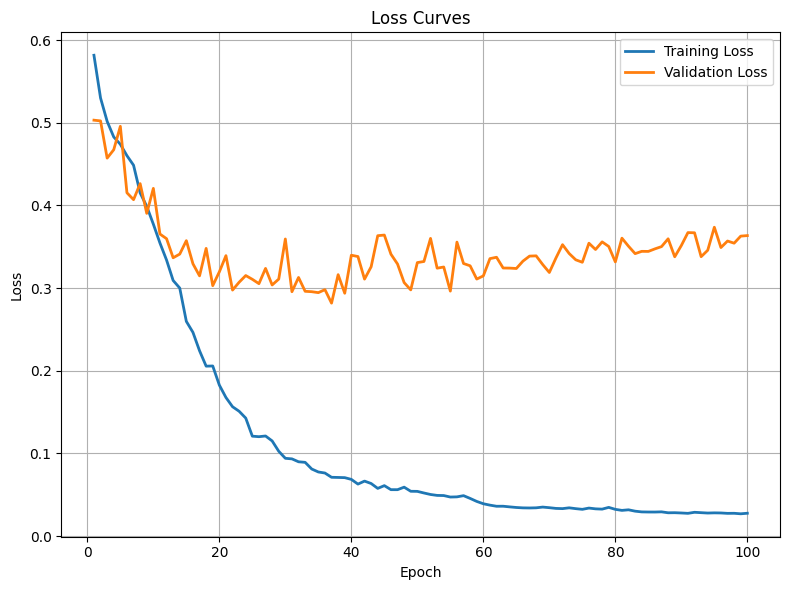

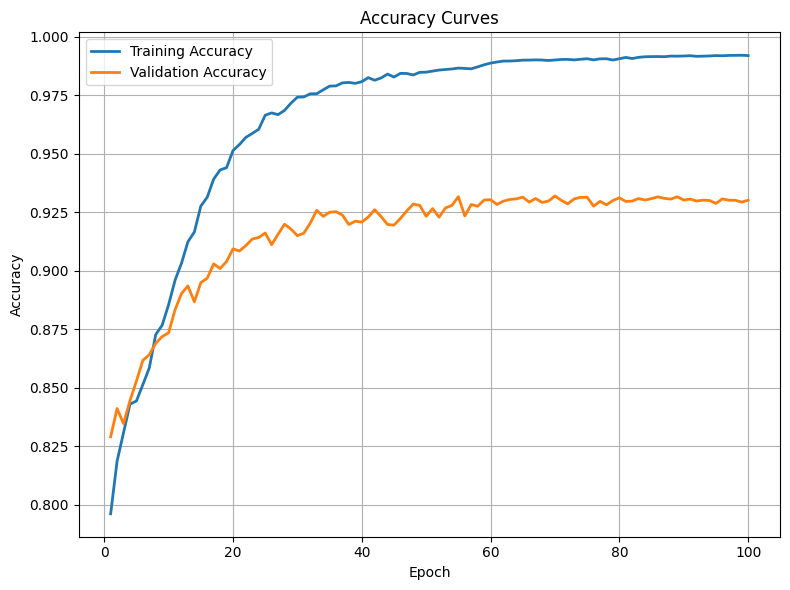

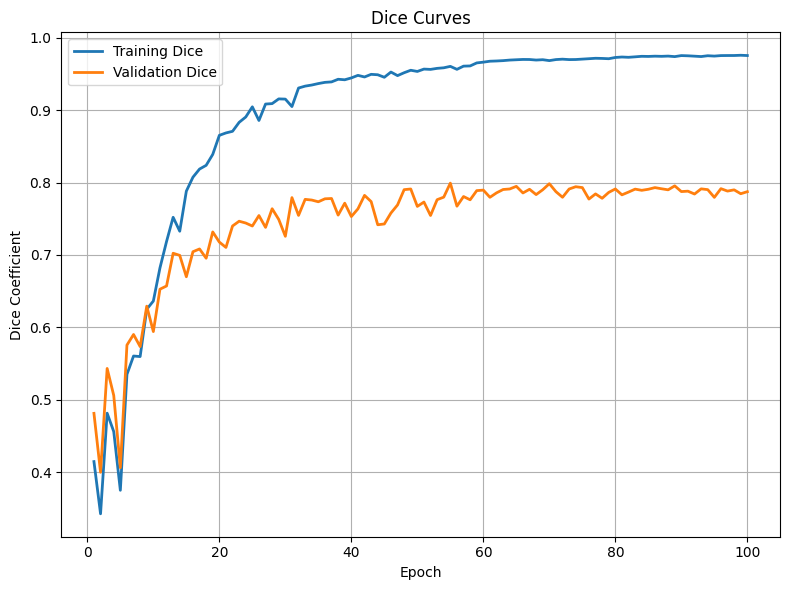

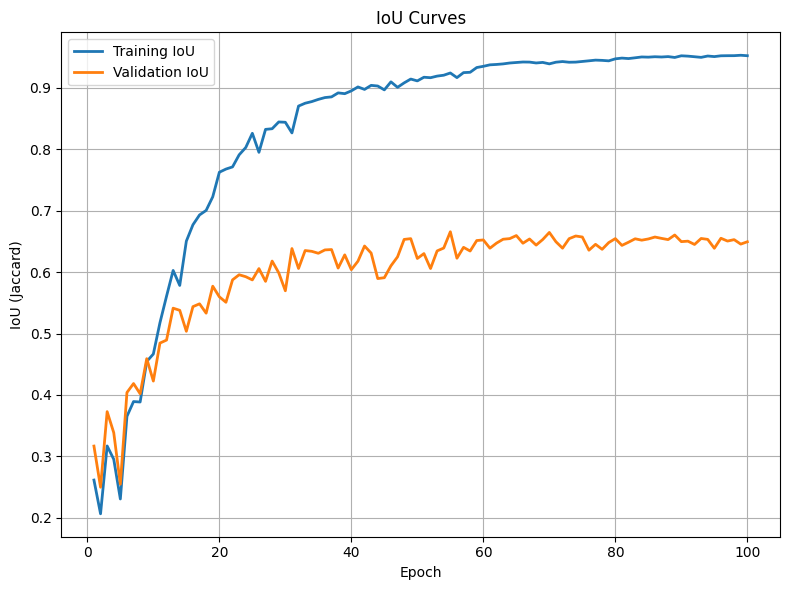

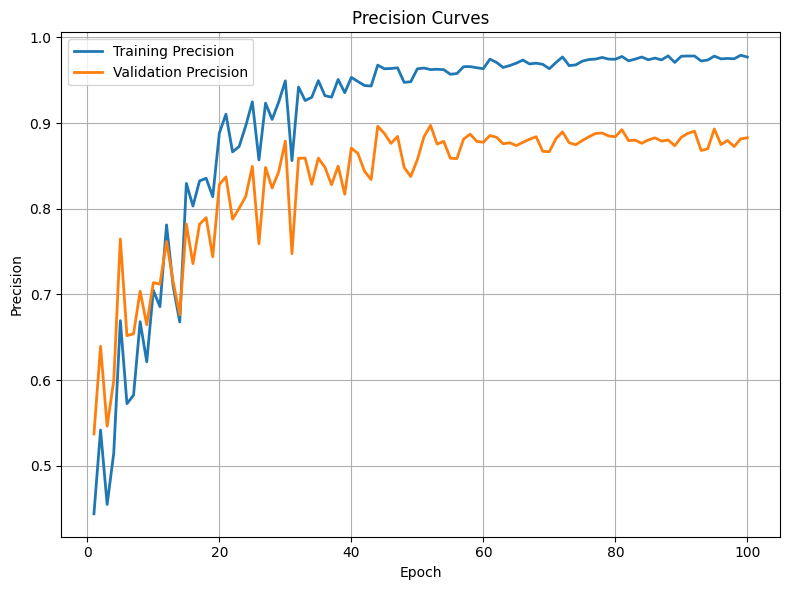

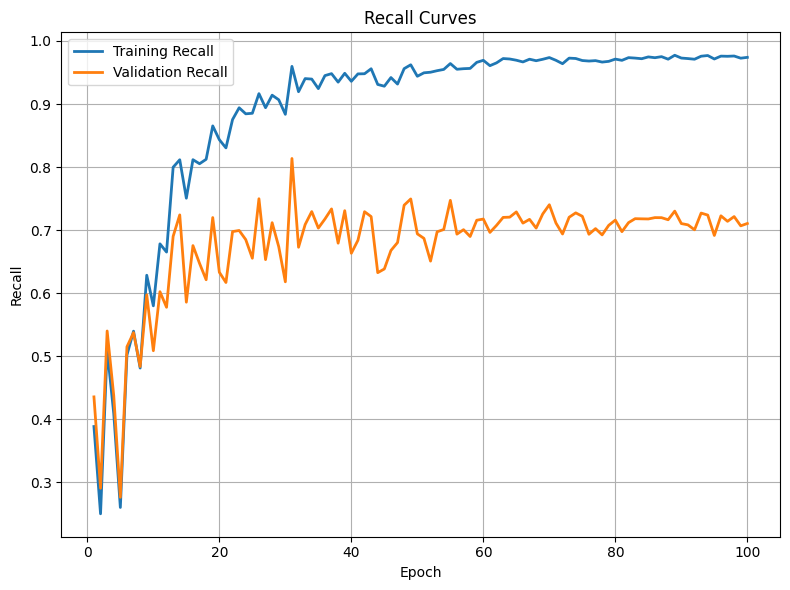

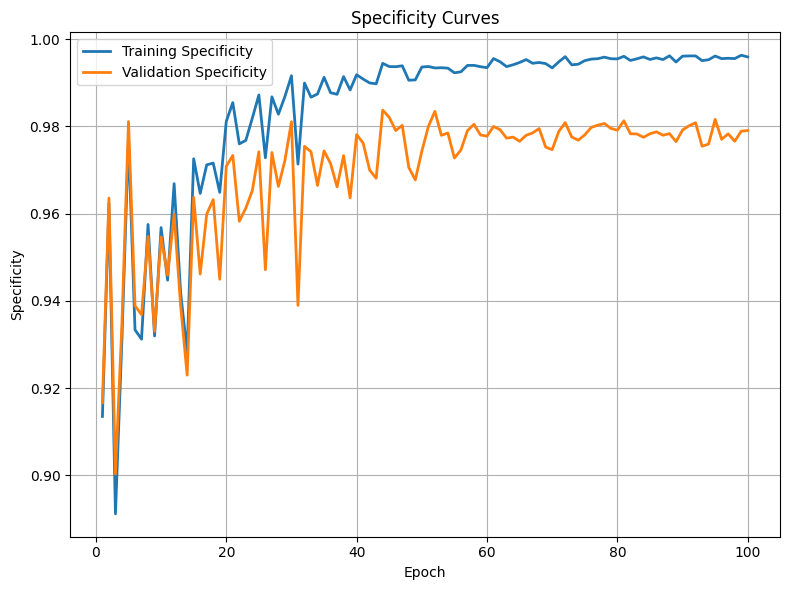

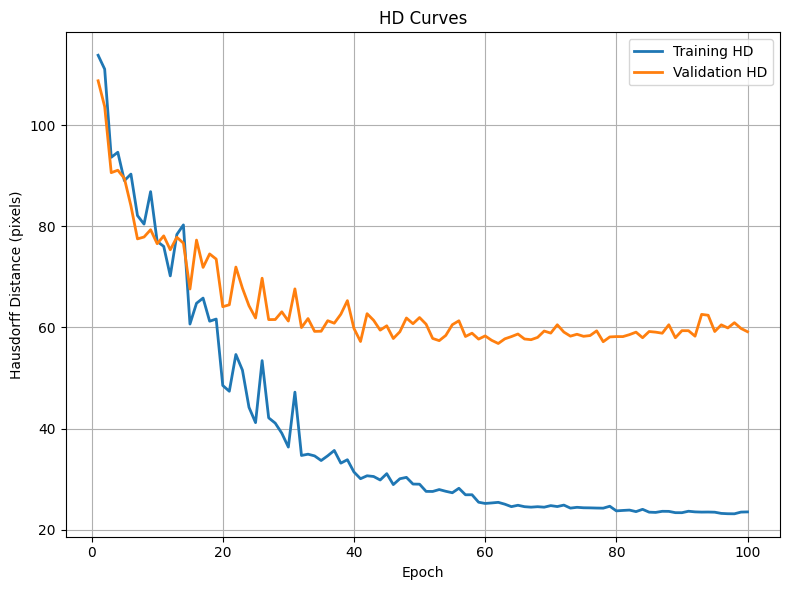

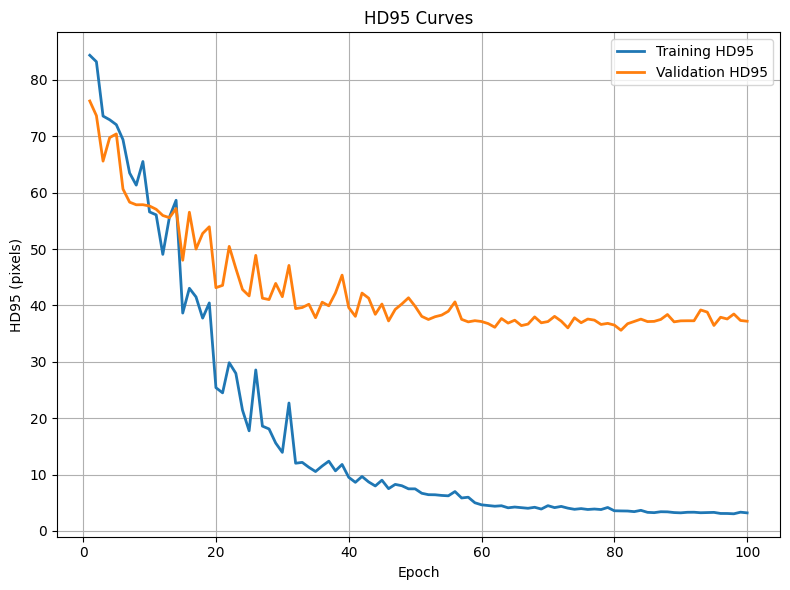

All plots saved to results/


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_training_curves(csv_path='logs/training_log.csv', save_dir='results'):
    """
    Reads the training log CSV and creates individual plots for:
    - Loss
    - Accuracy
    - Dice
    - Jaccard (IoU)
    - Precision
    - Recall
    - Specificity
    - HD (Hausdorff distance)
    - HD95
    
    Each plot shows both training and validation curves over epochs.
    """
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    epochs = df['epoch']

    # 1. Loss
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_loss'], label='Training Loss', linewidth=2)
    plt.plot(epochs, df['val_loss'], label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'loss_curve.png'), dpi=300)
    plt.show()

    # 2. Accuracy
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_accuracy'], label='Training Accuracy', linewidth=2)
    plt.plot(epochs, df['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'accuracy_curve.png'), dpi=300)
    plt.show()

    # 3. Dice coefficient
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_dice'], label='Training Dice', linewidth=2)
    plt.plot(epochs, df['val_dice'], label='Validation Dice', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Dice Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'dice_curve.png'), dpi=300)
    plt.show()

    # 4. Jaccard (IoU)
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_jaccard'], label='Training IoU', linewidth=2)
    plt.plot(epochs, df['val_jaccard'], label='Validation IoU', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('IoU (Jaccard)')
    plt.title('IoU Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'iou_curve.png'), dpi=300)
    plt.show()

    # 5. Precision
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_precision'], label='Training Precision', linewidth=2)
    plt.plot(epochs, df['val_precision'], label='Validation Precision', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.title('Precision Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'precision_curve.png'), dpi=300)
    plt.show()

    # 6. Recall
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_recall'], label='Training Recall', linewidth=2)
    plt.plot(epochs, df['val_recall'], label='Validation Recall', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.title('Recall Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'recall_curve.png'), dpi=300)
    plt.show()

    # 7. Specificity
    plt.figure(figsize=(8,6))
    plt.plot(epochs, df['train_specificity'], label='Training Specificity', linewidth=2)
    plt.plot(epochs, df['val_specificity'], label='Validation Specificity', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Specificity')
    plt.title('Specificity Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'specificity_curve.png'), dpi=300)
    plt.show()

    # 8. Hausdorff Distance (HD and HD95) – note: these are usually validation only (you may not have training versions)
    # If training HD and HD95 are not in the CSV, skip them.
    if 'train_hd_mean' in df.columns and 'val_hd_mean' in df.columns:
        plt.figure(figsize=(8,6))
        plt.plot(epochs, df['train_hd_mean'], label='Training HD', linewidth=2)
        plt.plot(epochs, df['val_hd_mean'], label='Validation HD', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Hausdorff Distance (pixels)')
        plt.title('HD Curves')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'hd_curve.png'), dpi=300)
        plt.show()

        plt.figure(figsize=(8,6))
        plt.plot(epochs, df['train_hd95_mean'], label='Training HD95', linewidth=2)
        plt.plot(epochs, df['val_hd95_mean'], label='Validation HD95', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('HD95 (pixels)')
        plt.title('HD95 Curves')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'hd95_curve.png'), dpi=300)
        plt.show()
    else:
        print("Training HD/HD95 not found in CSV. Plotting validation only.")
        plt.figure(figsize=(8,6))
        plt.plot(epochs, df['val_hd_mean'], label='Validation HD', linewidth=2)
        plt.plot(epochs, df['val_hd95_mean'], label='Validation HD95', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Distance (pixels)')
        plt.title('Validation Hausdorff Distances')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'val_hausdorff.png'), dpi=300)
        plt.show()

    print(f"All plots saved to {save_dir}/")

# Run the plotting
plot_training_curves(csv_path='logs/training_log.csv', save_dir='results')

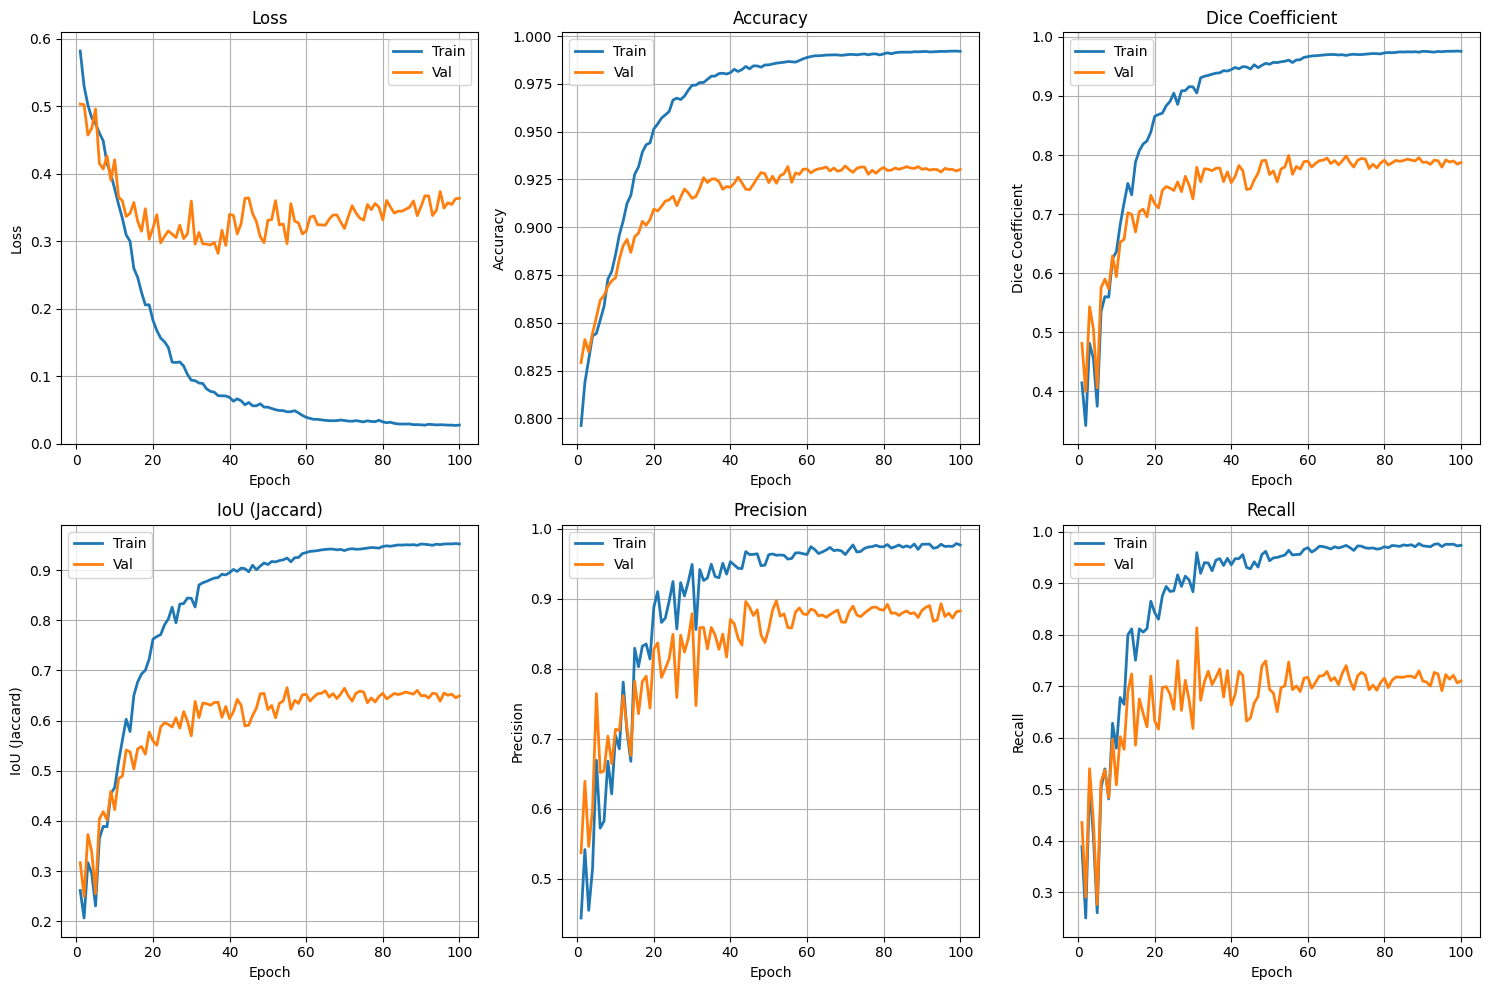

In [24]:
def plot_combined_curves(csv_path='logs/training_log.csv', save_dir='results'):
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    epochs = df['epoch']

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    metrics = [
        ('loss', 'Loss'),
        ('accuracy', 'Accuracy'),
        ('dice', 'Dice Coefficient'),
        ('jaccard', 'IoU (Jaccard)'),
        ('precision', 'Precision'),
        ('recall', 'Recall')
    ]

    for ax, (metric, title) in zip(axes.flatten(), metrics):
        ax.plot(epochs, df[f'train_{metric}'], label='Train', linewidth=2)
        ax.plot(epochs, df[f'val_{metric}'], label='Val', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'combined_curves.png'), dpi=300)
    plt.show()

plot_combined_curves()

# 16. Visualize Test Predictions

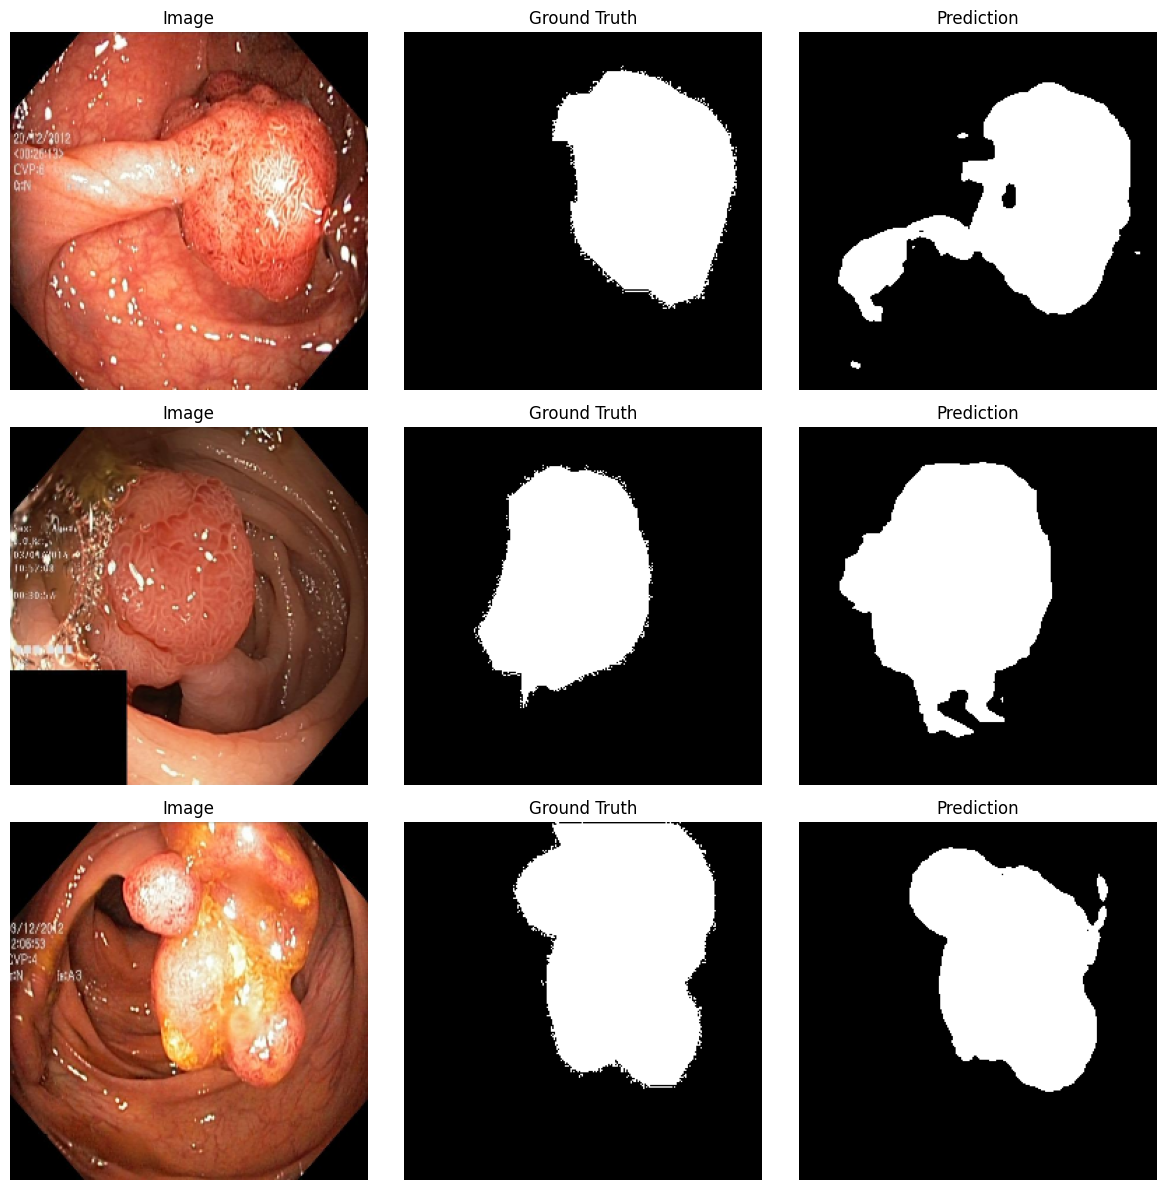

In [32]:
def visualize_test_predictions(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))
    indices = random.sample(range(len(dataset)), num_samples)

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            pred = (torch.sigmoid(output) > 0.5).squeeze().cpu().numpy().astype(np.uint8)  # <-- FIX: use .squeeze()

        # Denormalize image
        img_np = img.permute(1,2,0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask.cpu().numpy()

        axes[row,0].imshow(img_np)
        axes[row,0].set_title('Image')
        axes[row,0].axis('off')

        axes[row,1].imshow(mask_np, cmap='gray')
        axes[row,1].set_title('Ground Truth')
        axes[row,1].axis('off')

        axes[row,2].imshow(pred, cmap='gray')
        axes[row,2].set_title('Prediction')
        axes[row,2].axis('off')

    plt.tight_layout()
    plt.savefig('results/test_predictions.png', dpi=150)
    plt.show()

# Call the function
visualize_test_predictions(model, test_dataset, num_samples=3)